In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from helper_functions import E_to_speed
from pade.pade import pade

# constants
c = 299792458
q_e =  1.60217646e-19
h_bar = 1.054571817e-34
epsilon_0 = 8.8541878188e-12

# lattice constant
a = 426e-9

In [2]:
conversion_factor = a**(-3/2)/np.sqrt(epsilon_0)
conversion_factor

np.float64(1208679722663082.2)

In [3]:
DIFF = h5py.File("Normalization-out/diff_PML_a28_r245.hdf5")
EMPTY = h5py.File("Normalization-out/empty_PML_a28-ex.hdf5")
E_ind = DIFF['ex']
E_ind = E_ind[()]*conversion_factor # convert E in MEEP units to SI
E_ind

array([[-0.0295071 , -0.00980397,  0.02513965, ..., -0.00122354,
        -0.0015528 ,  0.02764659],
       [ 0.02690425,  0.00132902,  0.00271284, ...,  0.00427213,
         0.00529119, -0.02884544],
       [ 0.02122802,  0.00869779, -0.02431882, ...,  0.00386591,
         0.00410636, -0.02148539],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.07074447,
         0.09520055, -0.74543956],
       [ 0.        ,  0.        ,  0.        , ..., -0.07597434,
        -0.03634632, -0.44710734],
       [ 0.        ,  0.        ,  0.        , ..., -0.0599863 ,
        -0.09072207,  1.00367884]], shape=(674, 2451))

In [4]:
distance = 28*a # 28 unit cells with a width of 426 nm
velocity = E_to_speed(1e5)*c
Time = distance/velocity
resolution = distance/E_ind.shape[0]
N = E_ind.shape[1] # length of time or frequency array (2451)
dt = Time/(N-1)
t = np.linspace(0,Time,N)
freqs = np.arange(0,int(N/2)+1)*2*np.pi/Time
resolution

1.76973293768546e-08

In [5]:
# FFT # Because of symmetry -> only keep first half corresponding to positive frequencies
E_hat = np.fft.fft(E_ind[()]).T[:int(N/2)+1]
E_hat = E_hat*dt
freqs = (np.fft.fftfreq(N,dt)*2*np.pi)[:int(N/2)+1] # corresponding angular frequencies (i.e. omega = 2pi k/Ndt, (k is in cylces per N))

In [6]:
# pade FT
w_max = 2*q_e/h_bar
freqs = np.linspace(0,w_max,N)
E_hat = np.zeros((E_ind.shape[0],len(freqs)), dtype='complex128')

for i, x in enumerate(E_ind):
    E_hat[i], freqs = pade(t,x,read_freq=freqs,baseline='none')
E_hat = E_hat.T

In [7]:
Gamma = np.zeros(len(freqs))
for i_omega, Ex_omega in enumerate(E_hat): # enumerate over the series of Ex(x)'s where each list corresponds to Ex(x) values for a different omega
    omega = freqs[i_omega]
    for px, Ex_x in enumerate(Ex_omega): # for given omega, iterate over all pixels in the Ex series, we need to integrate over x
        dx = resolution
        x = dx*(px+0.5) # take the center of the pixel to represent the position of the electron

        # Accumulate the integral values
        # Gamma[i_omega] += ( Ex_x.real*np.cos(omega*x/velocity) - Ex_x.imag*np.sin(omega*x/velocity) )*dx
        Gamma[i_omega] += ( Ex_x*np.exp((omega*x/velocity)*1j) ).real*dx
    Gamma[i_omega] = (q_e/(np.pi*h_bar*omega))*Gamma[i_omega]
Gamma[0] = 0

/tmp/ipykernel_26301/4125710860.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  Gamma[i_omega] = (q_e/(np.pi*h_bar*omega))*Gamma[i_omega]


Text(0, 0.5, 'Loss probability %')

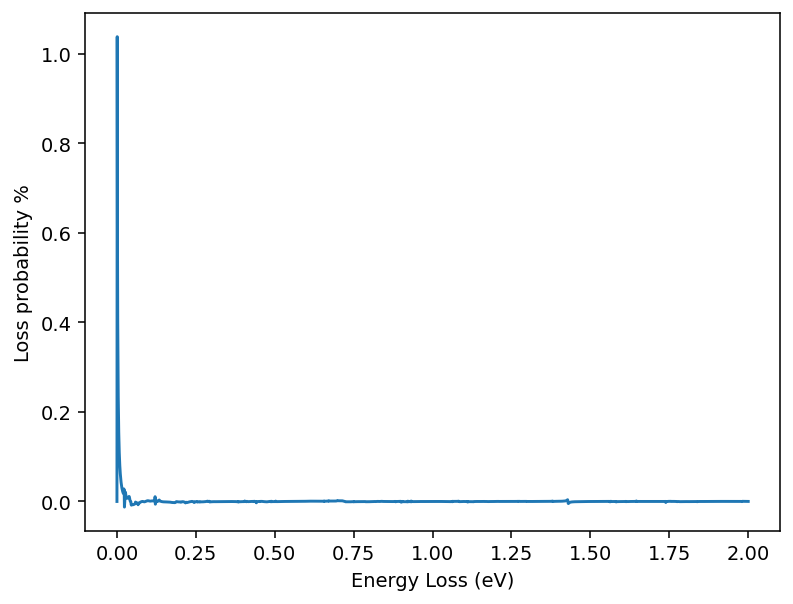

In [8]:
plt.figure(dpi=140)
# plt.plot(freqs[:int(N/2)+1]*h_bar/q_e, Gamma[:int(N/2)+1]*100)
plt.plot(freqs*h_bar/q_e, Gamma*100)
# plt.hlines(y=0,xmin=0,xmax=6, ls='--', lw=1, color='grey')
plt.xlabel('Energy Loss (eV)')
plt.ylabel('Loss probability %')
# plt.xlim((0,2))

## Convolution with gaussian

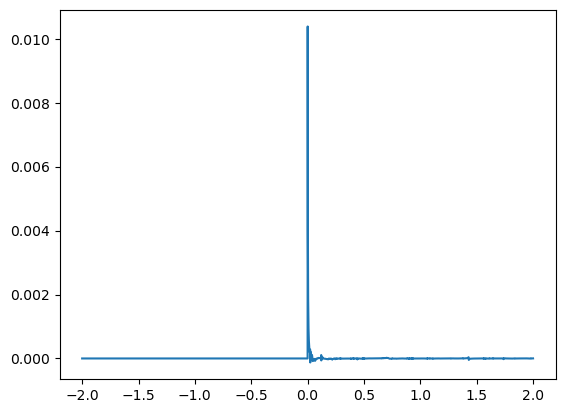

In [9]:
Gamma_ext = np.append(np.zeros(len(freqs)-1), Gamma)
freqs_ext = np.append((freqs[1:]*-1)[::-1],freqs)
plt.plot(freqs_ext*h_bar/q_e, Gamma_ext)

In [10]:
def gaussian(x, mu, sigma):
    return 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-(x-mu)**2/(2*sigma**2))

In [11]:
FWHM = 30e-3 # eV  # = 2*np.sqrt(2*np.log(2)) * sigma
sigma = FWHM/(2*np.sqrt(2*np.log(2)))

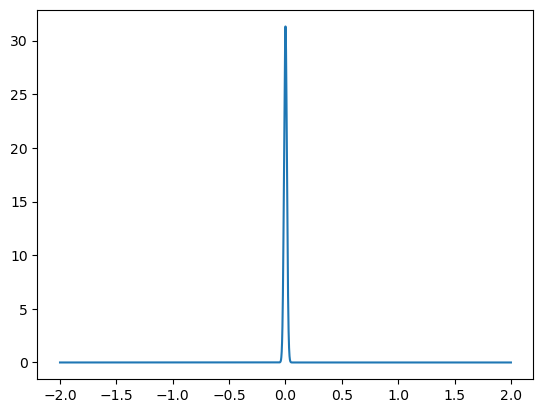

In [12]:
t = np.linspace(freqs[0],freqs[-1],len(freqs))
scale = t[-1]/(freqs[-1]*h_bar/q_e)
gauss = gaussian(freqs_ext*h_bar/q_e, 0, sigma)
plt.plot(freqs_ext*h_bar/q_e, gauss)

In [13]:
Gamma_c = np.convolve(Gamma_ext, gauss, mode='same')

(-0.25, 2.0)

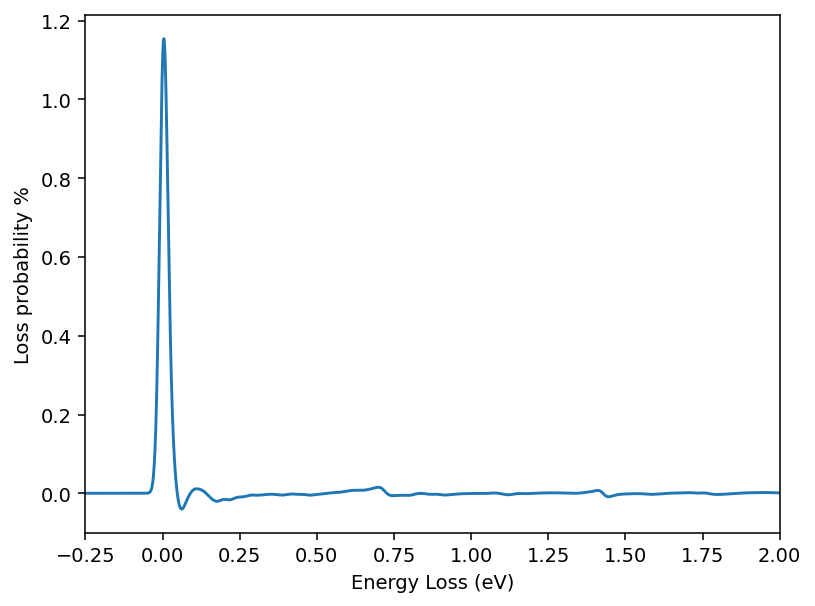

In [14]:
plt.figure(dpi=140)
plt.plot(freqs_ext*h_bar/q_e, Gamma_c)
# plt.hlines(y=0,xmin=-0.25,xmax=2, ls='--', lw=0.5, color='grey')
plt.xlabel('Energy Loss (eV)')
plt.ylabel('Loss probability %')
plt.xlim((-0.25,2))